## Pumpkin Pricing

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

- Only get pumpkins priced by the bushel
- Convert the date to a month
- Calculate the price to be an average of high and low prices
- Convert the price to reflect the pricing by bushel quantity

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv('../data/US-pumpkins.csv')

pumpkins.head()


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [2]:
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

columns_to_select = ['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)

new_pumpkins = pd.DataFrame(
    {'Month': month, 
     'DayOfYear' : day_of_year, 
     'Variety': pumpkins['Variety'], 
     'City': pumpkins['City Name'], 
     'Package': pumpkins['Package'], 
     'Low Price': pumpkins['Low Price'],
     'High Price': pumpkins['High Price'], 
     'Price': price})

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/1.1
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price*2

new_pumpkins.head()


/var/folders/gb/_y7zv7lx7q9fqy4xlhb66mgr0000gn/T/ipykernel_23460/2637987050.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)


,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.454545
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364


A basic scatterplot reminds us that we only have month data from August through December. We probably need more data to be able to draw conclusions in a linear fashion.

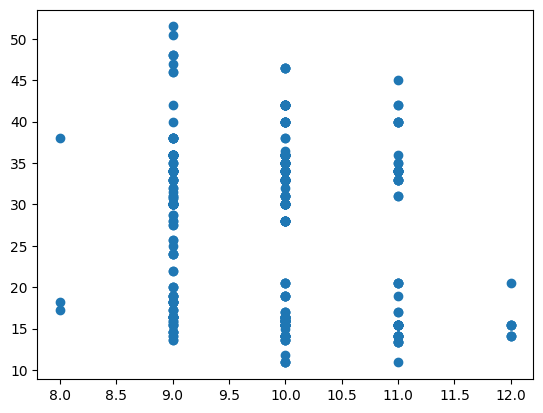

In [3]:
import matplotlib.pyplot as plt
plt.scatter('Month','Price',data=new_pumpkins)

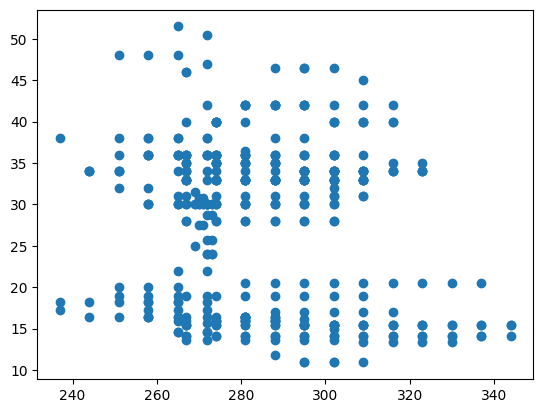

In [4]:

plt.scatter('DayOfYear','Price',data=new_pumpkins)

In [5]:
# Print collection between month and price

print(new_pumpkins['Month'].corr(new_pumpkins['Price']))

# Print the collection between Day of the year and price

print(new_pumpkins['DayOfYear'].corr(new_pumpkins['Price']))

-0.14878293554077526
-0.1667332249274541


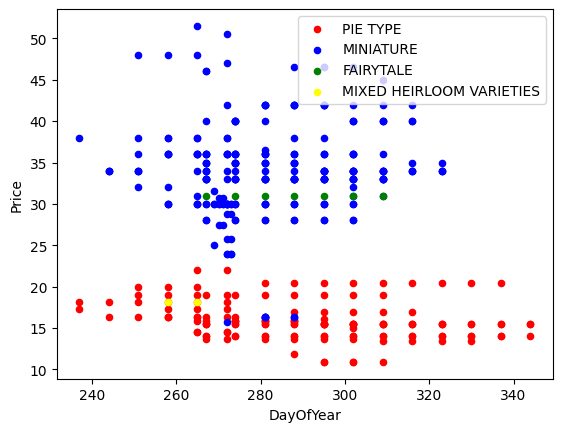

In [6]:
# Define the colors to use to plot the pumpkins

colors= [ 'red', 'blue', 'green', 'yellow']

# Plot the price vs day of year for the pumpkins, using different color for each variety 

ax=None
for i, var in enumerate(new_pumpkins['Variety'].unique()):
  df = new_pumpkins[new_pumpkins['Variety'] == var]
  ax = df.plot.scatter('DayOfYear', 'Price', ax=ax, c = colors[i], label=var)

<Axes: xlabel='DayOfYear', ylabel='Price'>

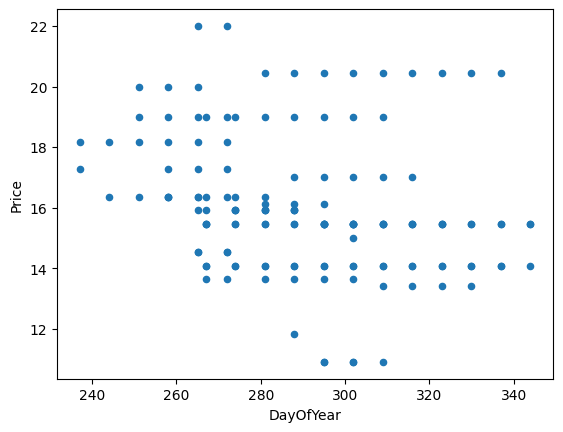

In [8]:
pie_pumpkins = new_pumpkins[new_pumpkins['Variety'] == 'PIE TYPE']
pie_pumpkins.plot.scatter('DayOfYear', 'Price')

In [10]:
# Print the collection betweeen month and price

print(pie_pumpkins['Month'].corr(pie_pumpkins['Price']))

# Print the collection between Day of the year and price

print(pie_pumpkins['DayOfYear'].corr(pie_pumpkins['Price']))

-0.23841413206125747
-0.2669192282197318


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [12]:
# Get the day of year and price in the separate array.

X = pie_pumpkins['DayOfYear'].to_numpy().reshape(-1, 1)
y = pie_pumpkins['Price']

# Print the shape

X.shape


(144, 1)

In [14]:
# Split the data into training and testing data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
# Create a linear regression object

lin_reg = LinearRegression()

# Train the model using our training data

lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.02]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,21.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[270.02]


In [16]:
# Test the model using our test data

pred = lin_reg.predict(X_test)
pred

array([16.21096253, 16.73652536, 16.08833121, 15.35254325, 15.96569988,
       16.73652536, 16.21096253, 16.36863138, 16.61389403, 15.84306855,
       15.84306855, 15.72043723, 16.21096253, 15.5978059 , 16.45622519,
       15.72043723, 15.5978059 , 16.08833121, 15.72043723, 16.36863138,
       16.85915669, 16.21096253, 15.22991192, 16.21096253, 15.84306855,
       16.45622519, 16.08833121, 15.84306855, 15.5978059 ])

In [ ]:
# Calcalute the mean squared error

mse = np.sqrt(mean_squared_error(y_test, pred))

# Print the mean square error in an easy to read format

print(f'Mean error: {mse: 3.3} ({mse/np.mean(pred) * 100:3.3}%)')

Mean error:  2.77 (17.2%)


In [ ]:
# Calculate the coefficient of the determination

score = lin_reg.score(X_train, y_train)
print("Model determination", score)


Model determination 0.04460606335028361


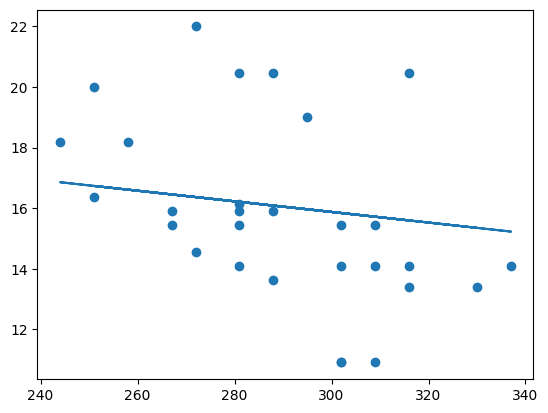

In [20]:
# Create the scatter plot using our data

plt.scatter(X_test, y_test)

# Add a line to the plot with the prediction

plt.plot(X_test, pred)

In [21]:
# Print the slope and interceptor

print(f"y = {lin_reg.coef_[0]}x + {lin_reg.intercept_}")

y = -0.017518760953105x + 21.133734359909326


In [26]:
lin_reg.predict([[256]])

array([16.64893156])

Mean error:  2.73 (17.0%)


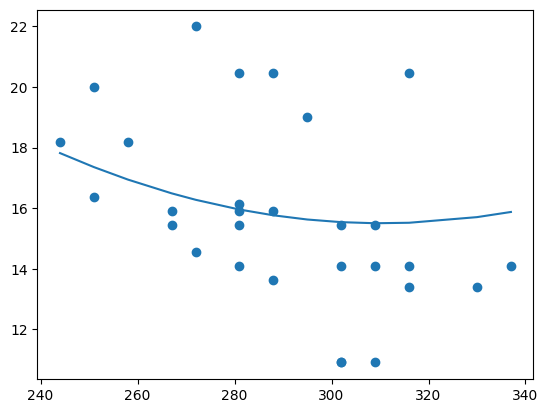

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Build a polynomial regression pipeline

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

# Use the pipeline to build a model

pipeline.fit(X_train, y_train)

# Test the model with our test data

pred = pipeline.predict(X_test)

# Calculate and print the mean squared error

mse = np.sqrt(mean_squared_error(y_test, pred))
print(f"Mean error: {mse: 3.3} ({mse / np.mean(pred) * 100:3.3}%)")

# Plot the result

plt.scatter(X_test, y_test)
plt.plot(sorted(X_test), pipeline.predict(sorted(X_test)))


In [29]:

# Score the model

score = pipeline.score(X_train, y_train)
print('Model determination', score)

Model determination 0.07639977655280206


In [ ]:
# Convert variety into a categoricak features

pd.get_dummies(new_pumpkins['Variety'])

#Get y value as the price

y = new_pumpkins['Price']


,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,False,False,False,True
71,False,False,False,True
72,False,False,False,True
73,False,False,False,True
74,False,False,False,True
...,...,...,...,...
1738,False,True,False,False
1739,False,True,False,False
1740,False,True,False,False
1741,False,True,False,False


In [33]:
# Get the  X value as a new data frame with the month column, along with the variety, city and package column converted into categorical features.

X = pd.get_dummies(new_pumpkins["Variety"]) .join(new_pumpkins['Month']).join(pd.get_dummies(new_pumpkins['City'])).join(pd.get_dummies(new_pumpkins['Package']))

# Get the Y value as the price

y = new_pumpkins['Price']

In [34]:
# make train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

# Create a linear regression object

lin_reg = LinearRegression()

# Train the model using our training data

lin_reg.fit(X_train, y_train)


# Train the model using the out test data

pred = lin_reg.predict(X_test)

# Calculate the mean  squarred

mse = np.sqrt(mean_squared_error(y_test, pred))
print(f"Mean error: { mse: 3.3} ({ mse / np.mean(pred) * 100:3.3}%)")

# Calculate the coefficient of determination

score = lin_reg.score(X_train, y_train)
print("Model determination", score)



Mean error:  2.84 (10.5%)
Model determination 0.9401401953107826


In [36]:
# make train test split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Setup  and train the pipeline

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

# Predict result for test data 

pred = pipeline.predict(X_test)

#calculate MSE and determination

mse = np.sqrt(mean_squared_error(y_test, pred))
print(f" Mean error: {mse:3.3} ({mse/np.mean(pred) * 100:3.3}%)")

score = pipeline.score(X_train, y_train)
print("Model determination", score)

 Mean error: 2.23 (8.28%)
Model determination 0.9653029999448537
